# 08 - Explaining the final model with SHAP

**Data used:** the **development data only** (all 226,980 rows, the data the final model learned from). No model is trained to be judged here and no split is made: the final model is rebuilt exactly as in notebook 06 (`fit_final_model`, reproducible), and the test group is never opened, so it stays used only once.

## What SHAP is

For every single transaction, the model's score starts at a **starting point** (its average score) and each of the 29 features **pushes** it up (more suspicious) or down (more genuine). **SHAP** (SHapley Additive exPlanations) measures each push, and the pushes always add up exactly to the score the model gave. The idea comes from game theory: the features are treated like players sharing out a prize fairly according to what each contributed.

A feature **matters most** if it gives big pushes across many transactions.

**Units: log-odds.** XGBoost works internally in **log-odds**, not probability. Odds = chance of fraud ÷ chance of genuine; log-odds is the natural logarithm of that. 0 means a 50/50 chance, every +1 multiplies the odds by about 2.7, every -1 divides them by 2.7. Pushes in log-odds add up neatly, which is why SHAP uses them; the final probability is `1 / (1 + e^(-log-odds))`.

**Method:** `shap.TreeExplainer` calculates SHAP values **exactly** for tree models, and quickly. Alternatives not used: `KernelExplainer` (only approximates, and would take hours here); XGBoost's built-in feature importance (shows how much a feature is used, not which direction it pushes, and its different versions disagree); permutation importance (needs held-out data, and the test group is not to be used again).

**Two checks before trusting it** (both first tried on a small toy model to confirm how shap behaves):
1. **The pushes add up:** for every row, starting point + all 29 pushes = the model's own raw score (`predict(..., output_margin=True)` gives the raw log-odds score instead of a probability).
2. **A second calculation agrees:** XGBoost can calculate SHAP values itself (`pred_contribs=True`); both should give the same numbers.

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

from src.walk_forward import feature_columns, fit_final_model, prepare_with_scaler

print(sys.executable)
print("shap version:", shap.__version__)

development = pd.read_csv("../data/processed/development.csv")
final_model, final_scaler = fit_final_model(development, feature_columns)
development_X = prepare_with_scaler(development, final_scaler, feature_columns)
development_y = development["Class"].to_numpy()
print(f"development rows: {len(development_X):,} | fraud: {development_y.sum()} | features: {development_X.shape[1]}")

C:\Users\RevathyHarichandran\Desktop\portfolio projects\Fraud_detection\.venv\Scripts\python.exe
shap version: 0.52.0


development rows: 226,980 | fraud: 399 | features: 29


In [2]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(development_X)
# expected_value is a one-item list before any calculation and a plain number
# after, so np.ravel (flatten into a simple list) + [0] (first item) works either way.
starting_point = np.ravel(explainer.expected_value)[0]
starting_probability = 1 / (1 + np.exp(-starting_point))
print("SHAP table shape (rows, features):", shap_values.shape)
print(f"starting point: {starting_point:.4f} log-odds, a probability of {starting_probability:.4f}")

# Check 1: starting point + the 29 pushes = the model's own raw score, row by row.
raw_scores = final_model.predict(development_X, output_margin=True)
rebuilt_scores = starting_point + shap_values.sum(axis=1)
print("check 1, largest gap between rebuilt and real raw score:", np.abs(rebuilt_scores - raw_scores).max())

# Check 2: XGBoost's own SHAP calculation. Its last column is the starting point.
xgboost_contributions = final_model.get_booster().predict(xgb.DMatrix(development_X), pred_contribs=True)
print("check 2, largest gap from XGBoost's own SHAP values:", np.abs(xgboost_contributions[:, :29] - shap_values).max())

SHAP table shape (rows, features): (226980, 29)
starting point: -0.2759 log-odds, a probability of 0.4315
check 1, largest gap between rebuilt and real raw score: 1.2397766e-05


check 2, largest gap from XGBoost's own SHAP values: 0.0


**What this shows:**
- **Both checks pass:** the pushes add back up to the model's raw score for every one of the 226,980 rows (largest gap 0.0000124, rounding only), and XGBoost's own calculation gives exactly the same values (gap 0.0). The SHAP values can be trusted.
- The starting point (-0.2759 log-odds, "probability" 0.43) is SHAP's reference point, not the model's average fraud chance (only 0.18% of development transactions are fraud). It is the same for every transaction, so it does not affect any ranking or explanation. The two obvious readings were checked and ruled out: it is not the plain average raw score (-13.72), nor the average with fraud counted 568 times for class weighting (-0.99). In this mode (tree_path_dependent, shap's default when no background data is given) shap takes the starting point from statistics stored in the trees during training, and the class weighting makes the training data look roughly balanced to the trees. That is the most likely explanation for a value near 0.5. Confirming the exact formula would need shap's background-data mode, which isn't compatible with this model setup (it stops with a "categorical split is not yet supported" error, although the model has no category columns). It does not affect anything below: the rankings and charts are built only from the pushes, which both checks confirm.

## The ranking: average push size per feature

For each feature, the **mean absolute SHAP value** (mean |SHAP|): the size of its push in every row, ignoring direction (`np.abs`), averaged over **all 226,980 rows**, no sampling. Bigger means the feature moves the model's decisions more. `share_of_total` is each feature's part of the sum of all 29.

Because 99.8% of rows are genuine, this all-rows ranking mostly reflects how the model recognises genuine transactions. So the table also gives the same average over the **399 fraud rows only** (`mean_abs_shap_fraud`), to see whether the same features drive the fraud decisions.

Saved as `outputs/tables/shap_feature_importance.csv`, and drawn as a bar chart, `outputs/figures/13_shap_importance_bar.png`.

   feature  mean_abs_shap  mean_abs_shap_fraud  share_of_total  rank_fraud_rows
0      V14         2.4618               6.6654          0.1604                1
1       V4         1.4896               1.3792          0.0971                3
2      V12         1.4521               0.9908          0.0946                4
3      V10         0.7451               2.1462          0.0486                2
4      V11         0.6553               0.3708          0.0427               12
5   Amount         0.6100               0.5743          0.0398                9
6      V16         0.6096               0.4926          0.0397               11
7       V3         0.5913               0.7056          0.0385                7
8       V8         0.5548               0.8242          0.0362                5
9       V1         0.4163               0.1454          0.0271               29
10      V5         0.4082               0.3146          0.0266               14
11     V19         0.3998               

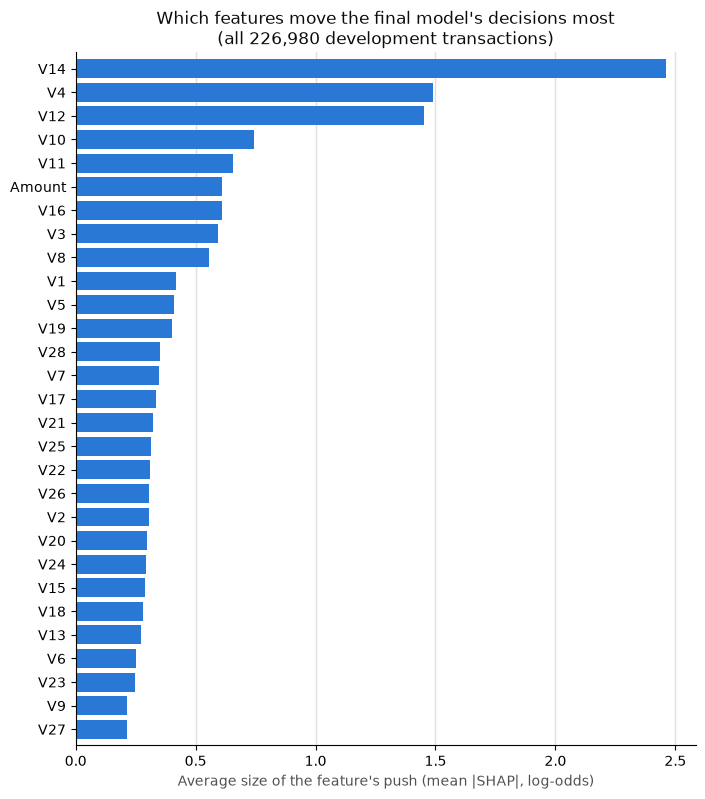

In [3]:
fraud_rows = development_y == 1

importance = pd.DataFrame({
    "feature": feature_columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_abs_shap_fraud": np.abs(shap_values[fraud_rows]).mean(axis=0),
})
importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
importance["share_of_total"] = importance["mean_abs_shap"] / importance["mean_abs_shap"].sum()
importance["rank_fraud_rows"] = importance["mean_abs_shap_fraud"].rank(ascending=False).astype(int)
importance.to_csv("../outputs/tables/shap_feature_importance.csv", index=False)
print(importance.round(4).to_string())

# Bar chart: sorted smallest first, because barh draws the first bar at the bottom,
# so the most important feature ends up on top.
plot_table = importance.sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(plot_table["feature"], plot_table["mean_abs_shap"], color="#2a78d6")
ax.set_xlabel("Average size of the feature's push (mean |SHAP|, log-odds)", color="#52514e")
ax.set_title("Which features move the final model's decisions most\n(all 226,980 development transactions)", color="#0b0b0b")
ax.grid(axis="x", color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(y=0.01)

fig.savefig("../outputs/figures/13_shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In the cell above, `.rank(ascending=False)` numbers the features 1, 2, 3, ... from largest to smallest; `.astype(int)` turns those ranks into whole numbers.

**What this shows:**
- **V14 matters far more than any other feature:** 16% of all pushing across all rows, and on the fraud rows its average push (6.67) is three times the next one (V10, 2.15).
- **Four features do 40% of the work:** V14, V4, V12 and V10 together account for 40% of all pushing (16.0% + 9.7% + 9.5% + 4.9%). The same four are the top four on the fraud rows too, in a slightly different order (V14, V10, V4, V12).
- **Amount is 6th of 29 overall** (4.0%) and 9th on the fraud rows. Covered in more detail in the next part.
- **Some features matter mainly for recognising genuine transactions:** V1 is 10th overall but last (29th) on the fraud rows. Others matter more for fraud than their overall rank suggests: V7 (14th overall, 6th on fraud) and V17 (15th overall, 8th on fraud).
- **No feature is unused:** even the smallest (V27, V9) carry about 1.4% each. That doesn't prove they help predictions; removing them was not tested.

## The SHAP summary chart (beeswarm)

**How to read it:** every dot is one transaction. Features are listed top to bottom by importance. A dot's **left-right position** is that feature's push for that transaction: right = towards fraud, left = towards genuine. Its **colour** is the feature's value in that transaction: red = high, blue = low (relative to that feature's own range; for Amount this is the scaled value, which keeps the same order as the real Amount). Where dots pile up, the chart spreads them vertically, like a swarm of bees.

**Which dots:** drawing all 226,980 is slow and the dots would pile on top of each other, and with only 399 fraud the picture would mostly show what looks genuine. So the chart draws **all 399 fraud + 4,601 genuine chosen at random** (seed 42, `rng.choice` with `replace=False` so no row is picked twice): 5,000 dots, fraud deliberately over-represented. (Alternative not used: a plain random 5,000, which would hold only about 9 fraud.)

**Order:** the chart would normally sort features by importance within the drawn dots, which over-represent fraud. `sort=False` with the columns given in the all-rows ranking order keeps the same order as the bar chart (confirmed on a toy model: the first column given is drawn at the top). `max_display=29` draws every feature (shap's default would show only the top 20).

`shap.summary_plot` draws on matplotlib's current figure; `show=False` stops it displaying straight away, so a title can be added and the figure saved first (`plt.gcf()` = "get current figure"). Saved as `outputs/figures/12_shap_summary.png`.

dots drawn: 5000 | fraud: 399


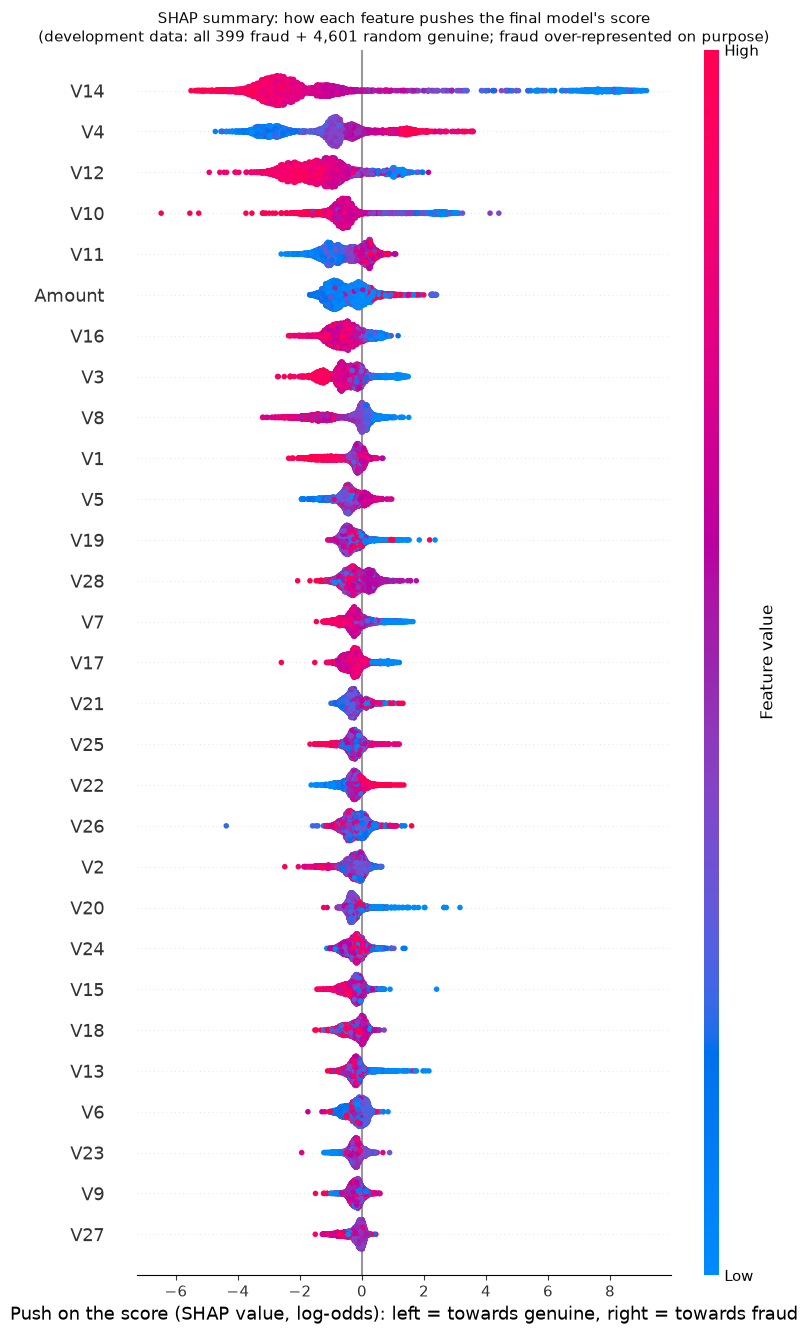

In [4]:
rng = np.random.default_rng(42)
fraud_positions = np.where(fraud_rows)[0]
genuine_positions = np.where(~fraud_rows)[0]
genuine_sample = rng.choice(genuine_positions, size=5000 - len(fraud_positions), replace=False)
sample_positions = np.concatenate([fraud_positions, genuine_sample])
print("dots drawn:", len(sample_positions), "| fraud:", development_y[sample_positions].sum())

# Put the columns in the all-rows ranking order, most important first.
ranked_features = importance["feature"].tolist()
ranked_positions = []
for feature in ranked_features:
    ranked_positions.append(feature_columns.index(feature))

sample_shap = shap_values[sample_positions][:, ranked_positions]
sample_X = development_X.iloc[sample_positions][ranked_features]

shap.summary_plot(sample_shap, sample_X, sort=False, max_display=29, show=False)
fig = plt.gcf()
plt.title("SHAP summary: how each feature pushes the final model's score\n"
          "(development data: all 399 fraud + 4,601 random genuine; fraud over-represented on purpose)",
          color="#0b0b0b", fontsize=11)
plt.xlabel("Push on the score (SHAP value, log-odds): left = towards genuine, right = towards fraud")
fig.savefig("../outputs/figures/12_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In the cell above, `np.where(fraud_rows)[0]` gives the positions of the fraud rows; `feature_columns.index(feature)` finds where a feature sits in the original column list, so the SHAP columns can be reordered to match.

**What this shows** (reading direction from colour and position):
- **V14:** **low** values (blue) push strongly towards fraud, by up to about +9 log-odds, the biggest single pushes in the whole chart. High values push towards genuine.
- **V4:** the other way round: **high** values (red) push towards fraud, low values towards genuine.
- **V12 and V10:** like V14, **low** values push towards fraud.
- **V11:** high values push mildly towards fraud.
- **Amount:** higher amounts tend to push towards fraud and lower amounts towards genuine, but the pushes are small (mostly within about ±2) and the colours are mixed. Looked at properly in the next part.
- **Most features further down** have pushes clustered near 0 for most transactions, with a few long tails: they matter for a minority of transactions only.

**Honest limits:**
- **What V14 or V4 mean can't be said:** the V columns are anonymized (PCA), so "low V14 points to fraud" is a true statement about this model, but nobody can say what real-world behaviour low V14 stands for.
- **SHAP explains the model, not the world:** it shows what this model relies on, not what causes fraud.
- **This is the data the model learned from:** it describes what the model learned, which is the point here; it is not a measure of how well the model performs.
- **The sample over-represents fraud on purpose** (399 of 5,000 dots, against 0.18% in reality), so the chart shows the fraud side clearly; the ranking order comes from all 226,980 rows.

# Part 2: The two readable columns, Amount and Time

The V columns are anonymized, so SHAP can say *that* they matter but not what they mean. Amount and Time are the only columns that can be described in real-world terms, so this part looks at them closely. **The key fact first: Amount is one of the model's 29 features; Time is not** (left out in notebook 05, where an hour-of-day feature was also tested and left out). So SHAP speaks directly about Amount, and about Time not at all.

Every point below is labelled **Shown** (a real number from the data or SHAP) or **Reasonable guess** (a possible *why* that can't be confirmed here).

## Amount

**1. Amount's push against the real Amount (a dependence plot):** one dot per development transaction (all 226,980; small and see-through so crowded areas look darker; fraud drawn on top in a different colour). Across: the real, unscaled Amount (from `development["Amount"]`, in the same row order as the SHAP values). Up: Amount's SHAP push. The bottom axis is a **log scale** (Amount runs from 0 to over 25,000). Exactly-zero amounts can't be placed on a log scale, so they are drawn at their own marked spot at the left edge. (Alternative not used: shap's `dependence_plot`, which would draw the *scaled* Amount and colour dots by another feature it picks itself.) Saved as `outputs/figures/14_shap_amount_dependence.png`.

**2. Average push by Amount band:** exactly 0, under 1, 1 to 10, 10 to 100, 100 to 1,000, 1,000 and over. Round numbers on the same ladder as the chart's log scale, fixed before seeing the results. Saved as `outputs/tables/shap_amount_by_band.csv`.

**3. Does Amount ever lead?** For each of the 399 frauds, which feature gave the **biggest push towards fraud** (`np.argmax` gives the position of the largest value in each row; `axis=1` means one answer per row). How often is that Amount?

In [5]:
amount_position = feature_columns.index("Amount")
amount_shap = shap_values[:, amount_position]
real_amount = development["Amount"].to_numpy()
print("smallest non-zero Amount:", real_amount[real_amount > 0].min(), "| exactly-zero amounts:", (real_amount == 0).sum())

# Average push by Amount band (bands fixed before seeing the results).
bands = [
    ["exactly 0", real_amount == 0],
    ["under 1", (real_amount > 0) & (real_amount < 1)],
    ["1 to 10", (real_amount >= 1) & (real_amount < 10)],
    ["10 to 100", (real_amount >= 10) & (real_amount < 100)],
    ["100 to 1,000", (real_amount >= 100) & (real_amount < 1000)],
    ["1,000 and over", real_amount >= 1000],
]
band_rows = []
for band_name, in_band in bands:
    band_rows.append({
        "amount band": band_name,
        "transactions": in_band.sum(),
        "fraud": development_y[in_band].sum(),
        "fraud rate": development_y[in_band].mean(),
        "average push, all": amount_shap[in_band].mean(),
        "average push, genuine": amount_shap[in_band & ~fraud_rows].mean(),
        "average push, fraud": amount_shap[in_band & fraud_rows].mean(),
    })
amount_bands = pd.DataFrame(band_rows)
amount_bands.to_csv("../outputs/tables/shap_amount_by_band.csv", index=False)
print(amount_bands.to_string(index=False, formatters={"fraud rate": "{:.3%}".format,
                                                      "average push, all": "{:+.3f}".format,
                                                      "average push, genuine": "{:+.3f}".format,
                                                      "average push, fraud": "{:+.3f}".format}))
print()

# For each fraud, which feature gave the biggest push towards fraud?
fraud_shap = shap_values[fraud_rows]
biggest_push_position = np.argmax(fraud_shap, axis=1)
biggest_push_feature = []
for position in biggest_push_position:
    biggest_push_feature.append(feature_columns[position])
print("Feature giving the biggest push towards fraud, across the 399 frauds:")
print(pd.Series(biggest_push_feature).value_counts().to_string())
print()
print("frauds where Amount pushes towards fraud at all:", (fraud_shap[:, amount_position] > 0).sum(), "of", fraud_rows.sum())
print("largest single Amount push on any transaction:", round(amount_shap.max(), 3),
      "| largest V14 push:", round(shap_values[:, feature_columns.index("V14")].max(), 3))

smallest non-zero Amount: 0.01 | exactly-zero amounts: 1556
   amount band  transactions  fraud fraud rate average push, all average push, genuine average push, fraud
     exactly 0          1556     20     1.285%            +0.551                +0.559              -0.002
       under 1         11356     26     0.229%            +0.160                +0.160              +0.151
       1 to 10         62287    148     0.238%            -0.236                -0.237              -0.150
     10 to 100        104598     95     0.091%            -0.885                -0.886              +0.375
  100 to 1,000         44653    103     0.231%            -0.232                -0.234              +0.631
1,000 and over          2530      7     0.277%            +0.349                +0.347              +0.876

Feature giving the biggest push towards fraud, across the 399 frauds:
V14       345
V4         25
V10         8
V20         5
Amount      4
V13         3
V24         2
V28         2
V19     

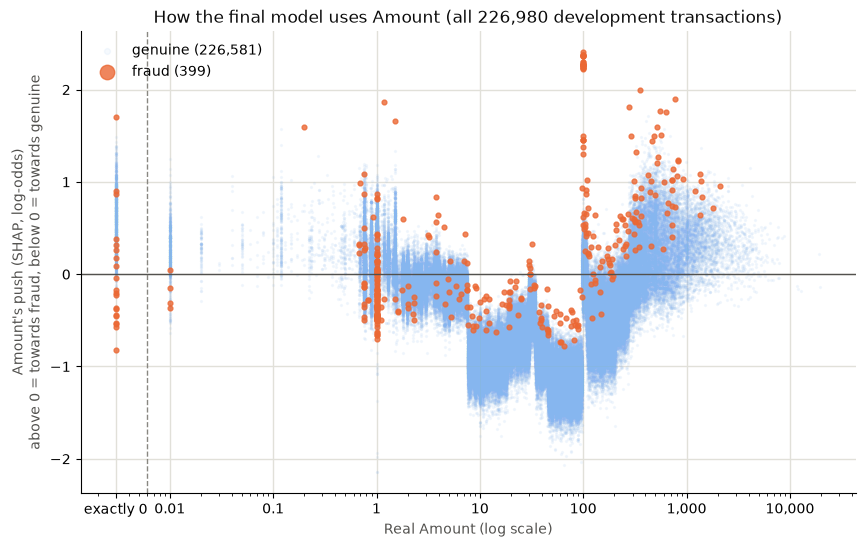

In [6]:
# Exactly-zero amounts can't go on a log scale, so they are drawn at 0.003,
# left of the smallest real amount (0.01), behind a dashed separator.
zero_spot = 0.003
plot_amount = real_amount.copy()
plot_amount[real_amount == 0] = zero_spot

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_amount[~fraud_rows], amount_shap[~fraud_rows], s=2, alpha=0.08, color="#86b6ef",
           label=f"genuine ({(~fraud_rows).sum():,})", rasterized=True)
ax.scatter(plot_amount[fraud_rows], amount_shap[fraud_rows], s=12, alpha=0.8, color="#eb6834",
           label=f"fraud ({fraud_rows.sum()})")
ax.axhline(0, color="#52514e", linewidth=1)
ax.axvline(0.006, color="#898781", linewidth=1, linestyle="--")

ax.set_xscale("log")
ax.set_xticks([zero_spot, 0.01, 0.1, 1, 10, 100, 1000, 10000])
ax.set_xticklabels(["exactly 0", "0.01", "0.1", "1", "10", "100", "1,000", "10,000"])
ax.set_xlabel("Real Amount (log scale)", color="#52514e")
ax.set_ylabel("Amount's push (SHAP, log-odds)\nabove 0 = towards fraud, below 0 = towards genuine", color="#52514e")
ax.set_title("How the final model uses Amount (all 226,980 development transactions)", color="#0b0b0b")
ax.legend(frameon=False, loc="upper left", markerscale=3)
ax.grid(color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.savefig("../outputs/figures/14_shap_amount_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Follow-up on the chart: the tall column of fraud dots just below 100.
big_amount_push = amount_shap > 2
print("transactions where Amount pushes by more than +2:", big_amount_push.sum(),
      "| of them fraud:", development_y[big_amount_push].sum())
print("their amounts:", pd.Series(real_amount[big_amount_push]).value_counts().to_dict())
print("fraud of exactly 99.99:", (fraud_rows & (real_amount == 99.99)).sum(),
      "| genuine of exactly 99.99:", (~fraud_rows & (real_amount == 99.99)).sum())
print(f"Amount's average push at exactly 99.99: fraud {amount_shap[fraud_rows & (real_amount == 99.99)].mean():+.3f}, "
      f"genuine {amount_shap[~fraud_rows & (real_amount == 99.99)].mean():+.3f}")

transactions where Amount pushes by more than +2: 21 | of them fraud: 21
their amounts: {99.99: 21}
fraud of exactly 99.99: 27 | genuine of exactly 99.99: 278
Amount's average push at exactly 99.99: fraud +2.105, genuine +0.033


**What this shows about Amount:**

**Shown (SHAP numbers):**
- **A U-shape: the middle looks safest, the extremes look riskier.** Average push by band: exactly 0 **+0.55**, under 1 +0.16, 1 to 10 -0.24, 10 to 100 **-0.89**, 100 to 1,000 -0.23, 1,000 and over **+0.35**. That matches the real fraud rate by band: highest at exactly 0 (1.29%), lowest at 10 to 100 (0.09%). It also matches notebook 02: fraud has more zero amounts and more large ones.
- **Amount is a supporting feature, not a leading one.** Its biggest push anywhere is +2.4, against +9.2 for V14. It gives the biggest push towards fraud for only **4 of the 399 frauds**; V14 does so for 345 (86%). For half the frauds (199 of 399) Amount pushes towards fraud at all.
- **The same amount gets a different push for fraud and for genuine.** In the 10 to 100 band, Amount pushes genuine transactions -0.89 on average but fraud +0.38. At exactly 0 it is the other way: genuine +0.56, fraud close to 0. So Amount's push depends on the transaction's other features (an **interaction**). Which features it interacts with was not examined.
- **The largest Amount pushes all go to one amount: exactly 99.99.** All 21 transactions where Amount pushes by more than +2 are frauds of exactly 99.99 (27 of the 399 development frauds have that amount). The 278 genuine transactions of 99.99 get almost no push (+0.03 on average), another interaction.
- **Steps rather than a smooth curve:** the push jumps at certain amounts (visible in the chart near about 8, 30, 100 and 200) and is fairly flat in between. That is how tree models work: each tree asks questions like "is Amount below some value?", so the push only changes where those dividing values sit. The exact dividing values were not looked up.

**Reasonable guesses (can't be confirmed here):**
- **Zero and tiny amounts:** fraudsters often test whether a stolen card works with a zero or very small charge before using it ("card testing"). That would fit the higher fraud rate at 0, but the data can't show intent.
- **Large amounts:** cashing out a stolen card quickly would favour large purchases. Again consistent, not proven.
- **99.99:** 27 frauds of exactly the same amount look like one repeated attack pattern, perhaps a purchase kept just under a 100 limit. If so, the model may partly be **remembering this particular attack** rather than learning a general rule, and a different attacker would not trigger it. This can't be checked without using the test data, which stays untouched.

## Time

**SHAP can't say anything about Time**, because the model never sees it. What *can* be checked is whether the model **behaves as if it knew the time anyway**, through the other features.

**The check:** for each hour since the first transaction (`Time // 3600`, notebook 02; the development data covers hours 0 to 40), put the real **fraud rate** next to the model's average raw score (log-odds) **for the genuine transactions only**.
- **Why genuine only:** on the data it learned from, the model gives fraud near-certain scores, so an average over all transactions would rise wherever there is more fraud, almost by arithmetic, and prove nothing. Genuine transactions are all the same answer; if the model is more suspicious of *genuine* transactions in the hours when fraud is common, it has picked up a time pattern from the other features without ever seeing Time.
- **Why raw scores:** probabilities for genuine transactions are squashed close to 0, where differences are invisible; the log-odds scale shows them. (Alternative not used: adding Time back and re-running SHAP, which would explain a *different* model from the one chosen.)
- **One summary number:** the **correlation** (notebook 02) between the hourly fraud rate and the hourly genuine score, across the 41 hours. A single number from 41 hours that overlap the same two nights, so it is supporting evidence, not a test.
- **Caveat:** this is the data the model learned from, so it shows what the model learned, not how well it performs.

Saved as `outputs/tables/scores_by_hour.csv` and `outputs/figures/15_scores_by_hour.png` (two panels sharing the same hours, `sharex=True`).

 hour  transactions  fraud fraud rate genuine average raw score
    0          3931      2     0.051%                   -13.740
    1          2213      2     0.090%                   -13.594
    2          1573     21     1.335%                   -13.279
    3          1818     13     0.715%                   -13.493
    4          1082      6     0.555%                   -13.084
    5          1679     11     0.655%                   -13.378
    6          1822      3     0.165%                   -13.281
    7          3366     23     0.683%                   -13.844
    8          5148      5     0.097%                   -13.751
    9          7841     15     0.191%                   -13.779
   10          8246      2     0.024%                   -13.753
   11          8474     43     0.507%                   -13.774
   12          7703      9     0.117%                   -13.766
   13          7565      9     0.119%                   -13.758
   14          8012     13     0.162%   

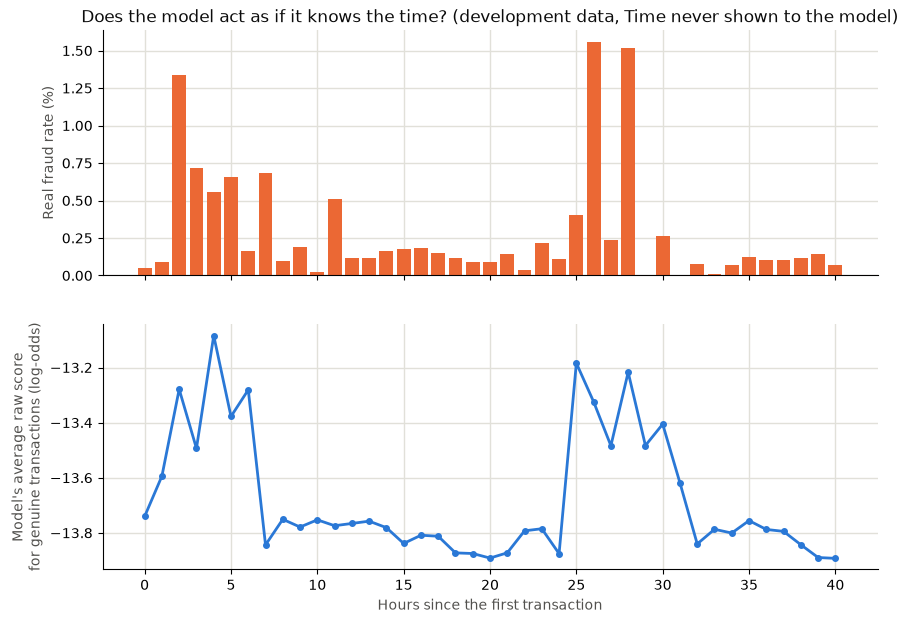

In [8]:
hour_number = (development["Time"] // 3600).to_numpy()

hour_rows = []
for hour in range(int(hour_number.max()) + 1):
    in_hour = hour_number == hour
    hour_rows.append({
        "hour": hour,
        "transactions": in_hour.sum(),
        "fraud": development_y[in_hour].sum(),
        "fraud rate": development_y[in_hour].mean(),
        "genuine average raw score": raw_scores[in_hour & ~fraud_rows].mean(),
    })
scores_by_hour = pd.DataFrame(hour_rows)
scores_by_hour.to_csv("../outputs/tables/scores_by_hour.csv", index=False)
print(scores_by_hour.to_string(index=False, formatters={"fraud rate": "{:.3%}".format,
                                                        "genuine average raw score": "{:.3f}".format}))
correlation = np.corrcoef(scores_by_hour["fraud rate"], scores_by_hour["genuine average raw score"])[0, 1]
print(f"\ncorrelation between hourly fraud rate and hourly genuine raw score: {correlation:.3f}")

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
top.bar(scores_by_hour["hour"], scores_by_hour["fraud rate"] * 100, color="#eb6834")
top.set_ylabel("Real fraud rate (%)", color="#52514e")
top.set_title("Does the model act as if it knows the time? (development data, Time never shown to the model)", color="#0b0b0b")
bottom.plot(scores_by_hour["hour"], scores_by_hour["genuine average raw score"], color="#2a78d6", linewidth=2, marker="o", markersize=4)
bottom.set_ylabel("Model's average raw score\nfor genuine transactions (log-odds)", color="#52514e")
bottom.set_xlabel("Hours since the first transaction", color="#52514e")
for ax in [top, bottom]:
    ax.grid(color="#e1e0d9", linewidth=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.savefig("../outputs/figures/15_scores_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

**Follow-up: which features carry the night-time rise?** SHAP can't speak about Time, but it can say which features' pushes change between quiet and busy hours. For genuine transactions only: each feature's average push in the **quiet hours** minus its average push in the **busy hours**.

**Quiet hours** = hours with fewer than 4,000 transactions, about half a typical daytime hour (around 8,000). This rule was set **after** seeing the hourly table above, so it is a description, not a test. It also picks up hour 40, which is only 20 minutes long (the end of the development data), not a quiet hour.

In [9]:
quiet_hour_list = scores_by_hour.loc[scores_by_hour["transactions"] < 4000, "hour"].tolist()
quiet = np.isin(hour_number, quiet_hour_list)
print("quiet hours:", quiet_hour_list)

genuine_quiet = ~fraud_rows & quiet
genuine_busy = ~fraud_rows & ~quiet
push_change = shap_values[genuine_quiet].mean(axis=0) - shap_values[genuine_busy].mean(axis=0)
print(f"genuine raw score, quiet minus busy: {raw_scores[genuine_quiet].mean() - raw_scores[genuine_busy].mean():+.3f}"
      f" (sum of all 29 push changes: {push_change.sum():+.3f})")

push_change_table = pd.DataFrame({"feature": feature_columns, "quiet minus busy": push_change})
push_change_table["size"] = push_change_table["quiet minus busy"].abs()
push_change_table = push_change_table.sort_values("size", ascending=False)
print(push_change_table[["feature", "quiet minus busy"]].head(8).to_string(index=False, formatters={"quiet minus busy": "{:+.3f}".format}))
amount_change = push_change_table.loc[push_change_table["feature"] == "Amount", "quiet minus busy"].iloc[0]
print(f"Amount: {amount_change:+.3f}")

quiet hours: [0, 1, 2, 3, 4, 5, 6, 7, 24, 25, 26, 27, 28, 29, 30, 31, 40]
genuine raw score, quiet minus busy: +0.247 (sum of all 29 push changes: +0.247)
feature quiet minus busy
    V14           -0.770
    V12           +0.707
     V4           +0.150
     V8           +0.132
    V11           +0.118
    V13           -0.094
    V15           +0.080
    V10           +0.071
Amount: -0.003


In the cell above, `np.isin(hour_number, quiet_hour_list)` marks each transaction whose hour is in the list; `.loc[condition, "hour"]` picks the `hour` column for the rows meeting the condition.

**What this shows about Time:**

**Shown:**
- **The model never sees Time, so it plays no direct role**, and SHAP has nothing to say about it.
- **But the model acts partly as if it knew the time.** Its average score for *genuine* transactions rises in the night-time hours (about hours 2 to 6 and 25 to 30), exactly where the real fraud rate peaks. The correlation between the hourly fraud rate and the hourly genuine score is **0.63** across the 41 hours.
- **The effect is clear but small in absolute terms.** The genuine average rises from about -13.8 log-odds in the daytime to about -13.1 at its night-time peak: roughly double the odds, but still a tiny probability (around 2 in a million). On its own, this shift comes nowhere near either cutoff for a typical genuine transaction: night-time transactions are looked at slightly more suspiciously, not flagged because of the hour.
- **It comes through the V columns, not through Amount.** Between quiet and busy hours the genuine score rises by +0.25 on average. That rise is the net result of V columns pulling in opposite directions (V12 +0.71, V14 -0.77, then smaller rises from V4, V8 and V11). Amount's push barely changes (-0.003).
- **This fits notebook 05's result:** an hour-of-day feature added nothing measurable, which is what you would expect if part of the time pattern already reaches the model.

**Caveats:** 41 hourly averages covering the same two nights, the quiet-hour rule chosen after seeing the table, and the data the model learned from. This describes what the model learned; it does not test anything.

**Reasonable guesses (can't be confirmed here):**
- Night-time transactions may differ in kind (for example more online purchases, or different types of shops), and the anonymized V columns may capture those differences, which would carry part of the time pattern in with them. The V columns can't be decoded, so this can't be checked.
- Whether the night pattern holds beyond these two days is unknown: two nights are too few to call it a rule.